In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

In [16]:

def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    TODO: Adapt the SIR model to include deaths

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y  # Note: now 4 compartments.
    N = S + I + R + D

    # TODO: Modify the SIR equations to include death
    # Hint: Infectious people can either recover (rate γ) OR die (rate μ)

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt

# Test your SIRD function
test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("You should see 4 numbers!")

SIRD test result: (-2.97, 1.87, 1.0, 0.1)
You should see 4 numbers!


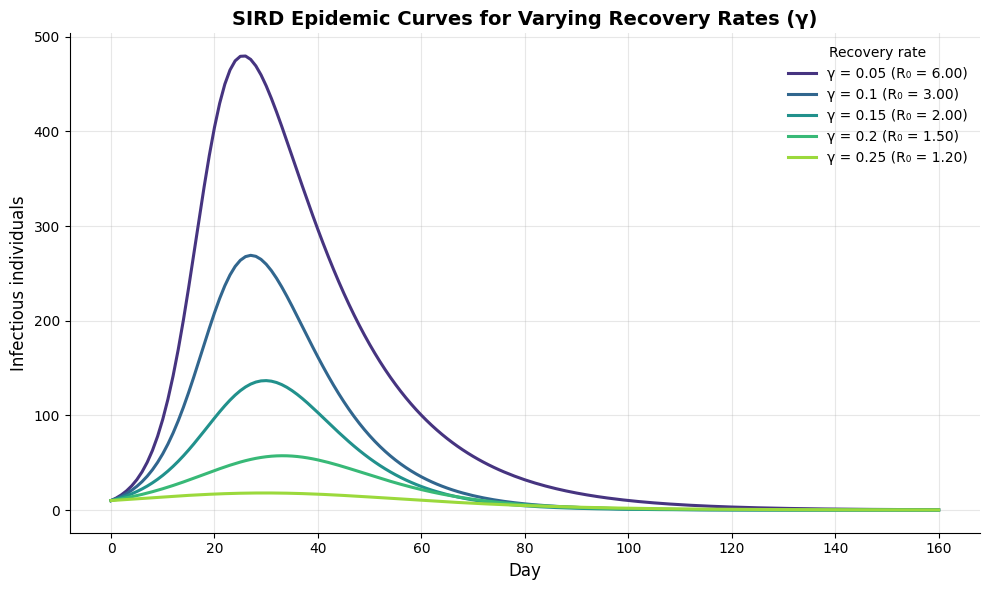

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,6.0,479.7,26.0,165.5
1,0.10,3.0,269.1,27.0,83.6
2,0.15,2.0,136.8,30.0,47.7
3,0.20,1.5,57.4,33.0,26.0
4,0.25,1.2,18.0,30.0,11.5


In [ ]:
def run_gamma_sensitivity_analysis(gamma_values, beta=0.3, mu=0.01,
                                    S0=990, I0=10, R0_init=0, D0=0, days=160):
    """
    Run the SIRD model for each recovery rate in gamma_values and summarize
    the epidemic outcomes.

    Returns
    -------
    results_df : pandas.DataFrame
        Columns: ['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths']
    fig : matplotlib.figure.Figure
        Epidemic curves (infectious individuals over time) for every gamma.
    """
    y0 = (S0, I0, R0_init, D0) # Initial conditions: S, I, R, D
    t = np.linspace(0, days, days + 1)

    records = [] # Store results for each gamma
    curves = {} # Store infectious curves for plotting

    for gamma in gamma_values:
        # Solve SIRD model for current gamma
        solution = odeint(sird_model, y0, t, args=(beta, gamma, mu))
        S, I, R, D = solution.T

        # Find peak infection metrics
        peak_idx = np.argmax(I)
        records.append({
            'gamma': gamma,
            'R0': beta / gamma,
            'peak_infected': I[peak_idx],
            'peak_day': t[peak_idx],
            'total_deaths': D[-1],
        })
        curves[gamma] = I

    results_df = pd.DataFrame(records, columns=['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths'])
    results_df = results_df.round({'gamma': 2, 'R0': 2, 'peak_infected': 1, 'peak_day': 0, 'total_deaths': 1})

    # --- Publication-quality plot ---
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(gamma_values)))

    for color, gamma in zip(colors, gamma_values):
        ax.plot(t, curves[gamma], color=color, linewidth=2.2,
                label=f'γ = {gamma} (R₀ = {beta / gamma:.2f})')

    ax.set_xlabel('Day', fontsize=12)
    ax.set_ylabel('Infectious individuals', fontsize=12)
    ax.set_title('SIRD Epidemic Curves for Varying Recovery Rates (γ)', fontsize=14, fontweight='bold')
    ax.legend(title='Recovery rate', frameon=False, fontsize=10)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()

    return results_df, fig


# Run the sensitivity analysis across the required recovery rates
gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]
results_df, fig = run_gamma_sensitivity_analysis(gamma_values)

plt.show()
results_df

High transmission results:


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.00,520.6,21.0,284.8
1,0.10,4.00,340.1,22.0,159.9
2,0.15,2.67,213.5,24.0,102.6
3,0.20,2.00,123.9,27.0,67.4
4,0.25,1.60,63.1,30.0,42.7


Low transmission results:


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.00,371.4,44.0,88.2
1,0.10,2.00,139.3,52.0,36.7
2,0.15,1.33,31.3,67.0,13.6
3,0.20,1.00,5.0,0.0,1.8
4,0.25,0.80,5.0,0.0,0.4


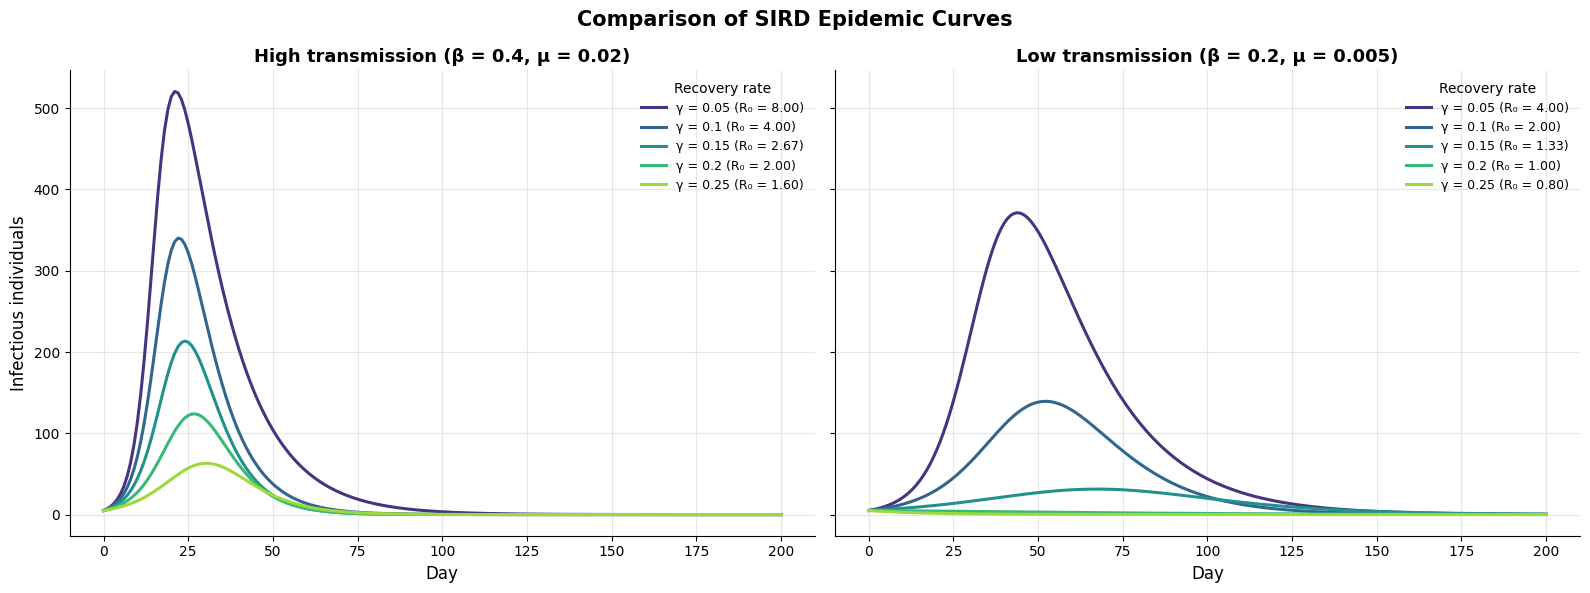

In [18]:
results_high_transmission, high_transmission_fig = run_gamma_sensitivity_analysis(
    gamma_values, beta=0.4, mu=0.02,
    S0=995, I0=5, R0_init=0, D0=0, days=200
)
results_low_transmission, low_transmission_fig = run_gamma_sensitivity_analysis(
    gamma_values, beta=0.2, mu=0.005,
    S0=995, I0=5, R0_init=0, D0=0, days=200
)

print('High transmission results:')
display(results_high_transmission)

print('Low transmission results:')
display(results_low_transmission)

# Compare both parameter scenarios using the curves generated above.
comparison_fig, comparison_axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
scenario_figures = [
    (high_transmission_fig, comparison_axes[0], 'High transmission (β = 0.4, μ = 0.02)'),
    (low_transmission_fig, comparison_axes[1], 'Low transmission (β = 0.2, μ = 0.005)'),
]

for source_fig, axis, title in scenario_figures:
    for source_line in source_fig.axes[0].lines:
        axis.plot(
            source_line.get_xdata(), source_line.get_ydata(),
            color=source_line.get_color(), linewidth=2.2,
            label=source_line.get_label()
        )
    axis.set_title(title, fontsize=13, fontweight='bold')
    axis.set_xlabel('Day', fontsize=12)
    axis.grid(alpha=0.3)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.legend(title='Recovery rate', frameon=False, fontsize=9)

plt.close(high_transmission_fig)
plt.close(low_transmission_fig)

comparison_axes[0].set_ylabel('Infectious individuals', fontsize=12)
comparison_fig.suptitle('Comparison of SIRD Epidemic Curves', fontsize=15, fontweight='bold')
comparison_fig.tight_layout()
plt.show()

High transmission with high mortality rate is worse for public health, as the peak of infection is considerably higher for the same rate of recovery, and also the total deaths at the end are a lot more. In addition, with a higher transmission rate, the basic reproduction number becomes higher as well, so more people become sick at the same time. This puts considerable preassure on medical facilities, as hospitals get full and staff and available treatment fall short. In contrast, when the infection is more spread out time-wise, like it is for low transmission, not as many people need medical attention at the same time, so occurences like not enough available space for everyone sick in the hospitals is a lot more rare. Therefore, the high transmission scenario poses a significantly bigger threat to public health.